In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
df_prices_one = pd.read_csv("prices_round_0_day_-1.csv", delimiter = ";")
df_prices_two = pd.read_csv("prices_round_0_day_-2.csv", delimiter = ";")
df_trades_one = pd.read_csv("trades_round_0_day_-1.csv", delimiter = ";")
df_trades_two = pd.read_csv("trades_round_0_day_-2.csv", delimiter = ";")

In [3]:
df_prices_one.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [4]:
df_prices_two.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0


In [5]:
df_trades_one.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5


In [6]:
df_trades_two.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5


In [7]:
# --- Data Preparation ---
import numpy as np

# Combine price data across both days
df_prices = pd.concat([df_prices_two, df_prices_one], ignore_index=True)

# Compute bid-ask spread (best bid/ask only)
df_prices["spread"] = df_prices["ask_price_1"] - df_prices["bid_price_1"]

# Combine trades across both days
df_trades = pd.concat([df_trades_two, df_trades_one], ignore_index=True)

# Split by product
products = df_prices["product"].unique()
print("Products:", products)
print("Price rows:", len(df_prices))
print("Trade rows:", len(df_trades))

Products: <StringArray>
['EMERALDS', 'TOMATOES']
Length: 2, dtype: str
Price rows: 40000
Trade rows: 1219


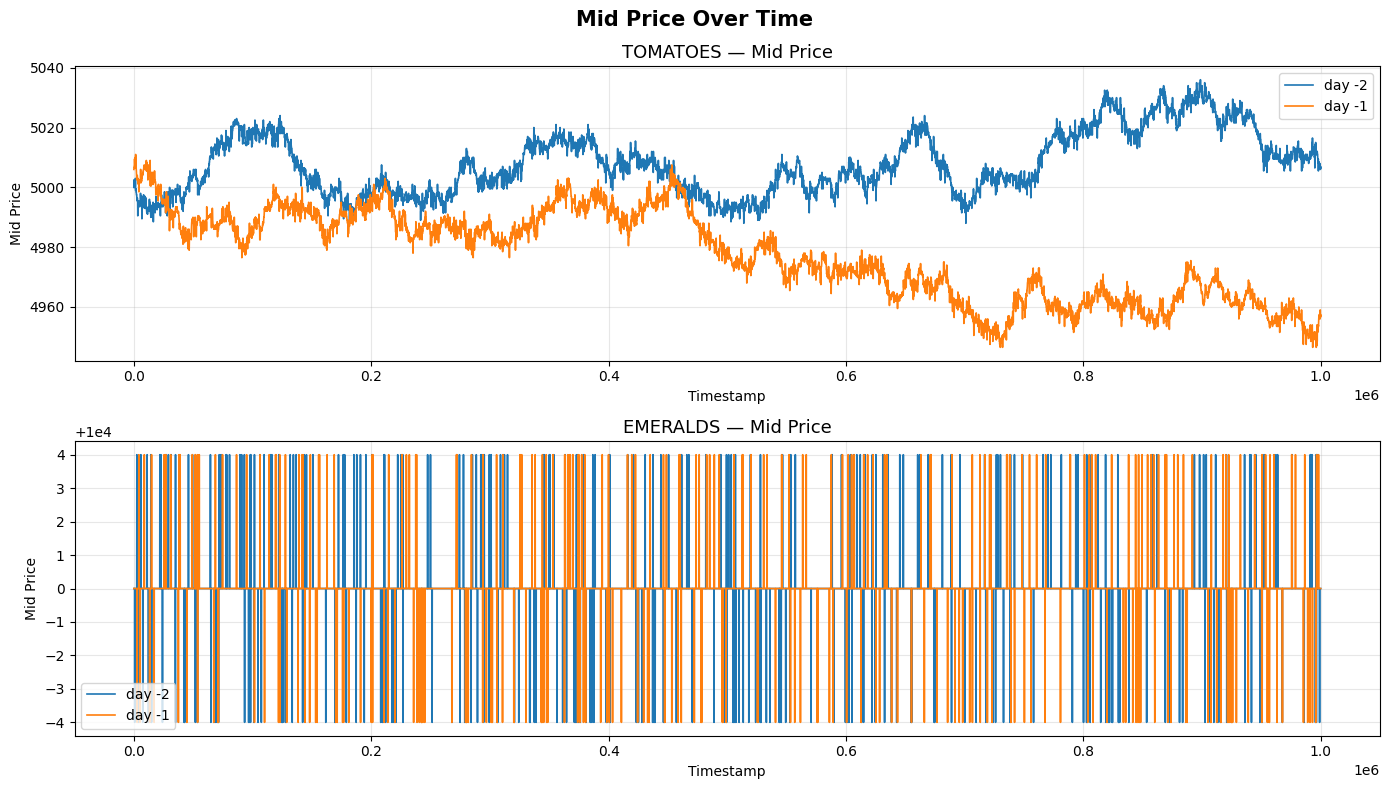

In [8]:
# --- 1. Mid Price Over Time (both products, both days) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

colors = {"day -2": "#1f77b4", "day -1": "#ff7f0e"}

for ax, product in zip(axes, ["TOMATOES", "EMERALDS"]):
    for day_val, label in [(-2, "day -2"), (-1, "day -1")]:
        subset = df_prices[(df_prices["product"] == product) & (df_prices["day"] == day_val)]
        ax.plot(subset["timestamp"], subset["mid_price"], label=label, color=colors[label], linewidth=1.2)
    ax.set_title(f"{product} — Mid Price", fontsize=13)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Mid Price")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Mid Price Over Time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

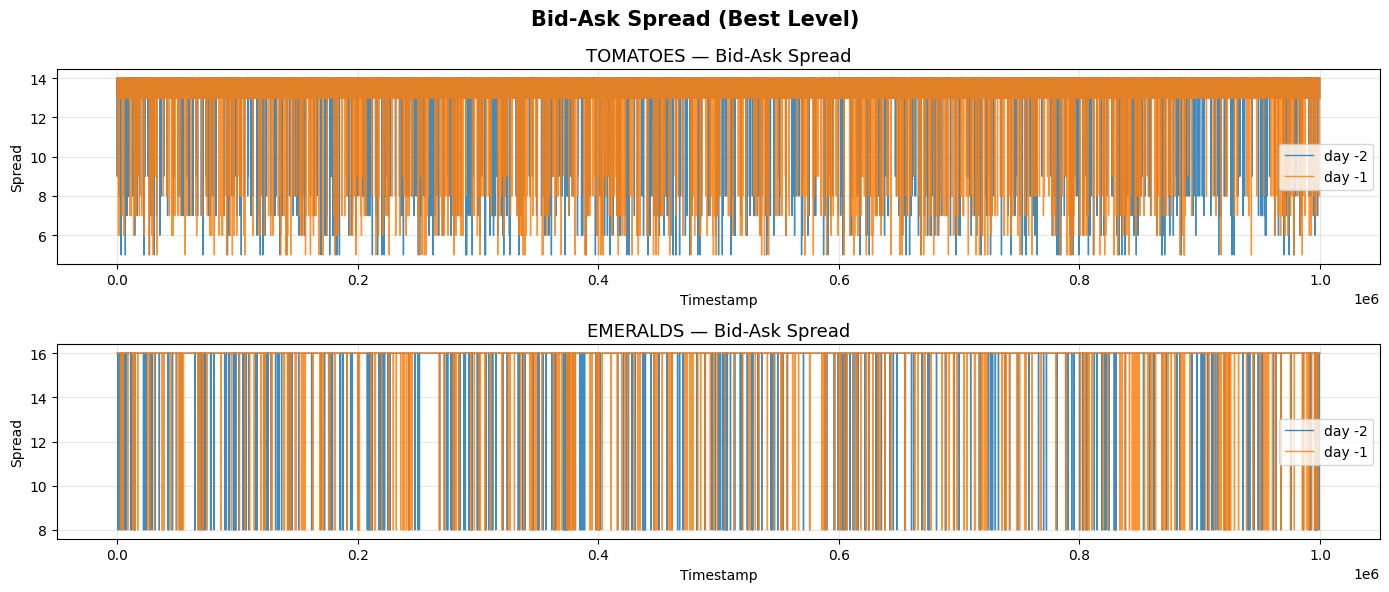

In [9]:
# --- 2. Bid-Ask Spread Over Time ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, product in zip(axes, ["TOMATOES", "EMERALDS"]):
    for day_val, label in [(-2, "day -2"), (-1, "day -1")]:
        subset = df_prices[(df_prices["product"] == product) & (df_prices["day"] == day_val)]
        ax.plot(subset["timestamp"], subset["spread"], label=label, linewidth=1.0, alpha=0.85)
    ax.set_title(f"{product} — Bid-Ask Spread", fontsize=13)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Spread")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Bid-Ask Spread (Best Level)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

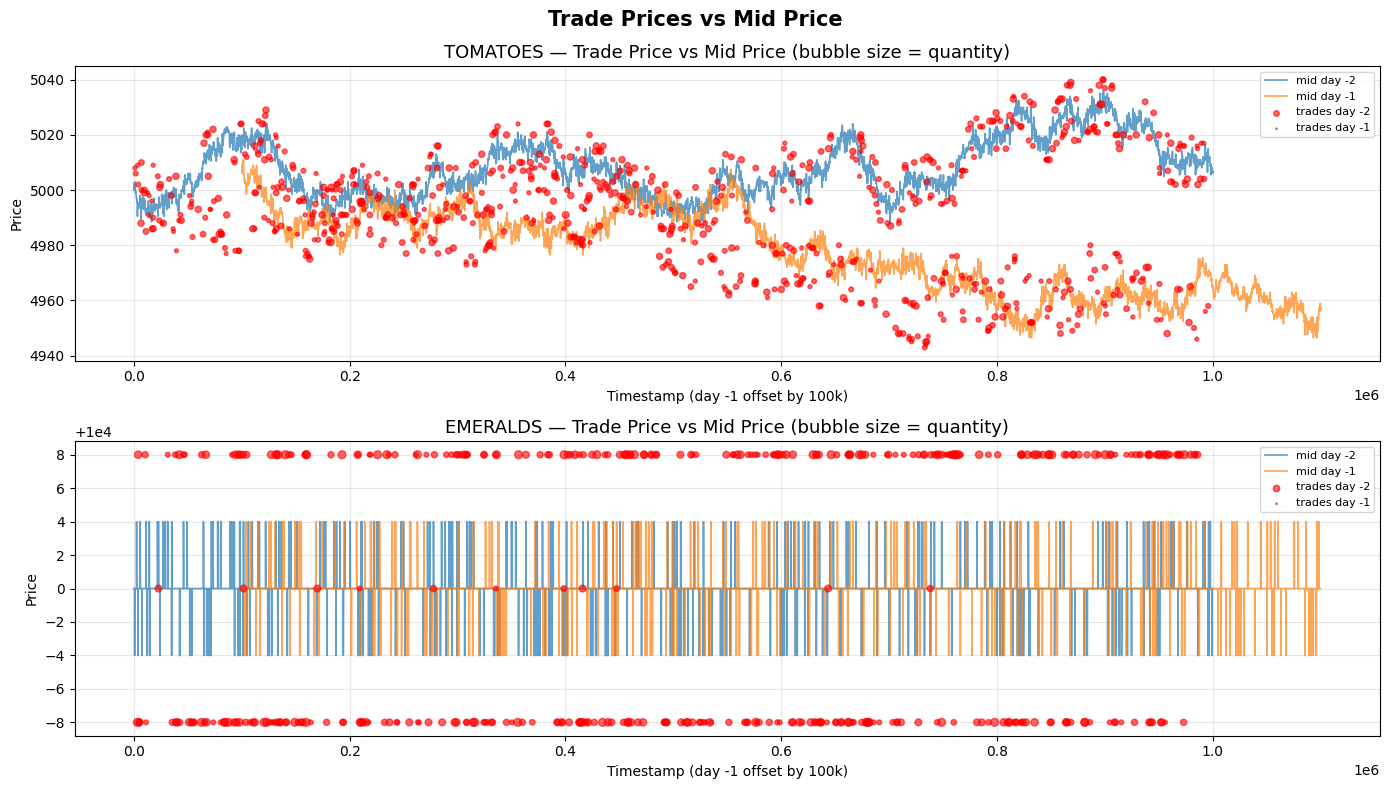

In [10]:
# --- 3. Trade Price vs Mid Price ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

symbol_to_product = {"TOMATOES": "TOMATOES", "EMERALDS": "EMERALDS"}

for ax, product in zip(axes, ["TOMATOES", "EMERALDS"]):
    # Mid price (both days combined)
    mid_subset = df_prices[df_prices["product"] == product].sort_values("timestamp")
    # Create a continuous x-axis offset for day -2 vs day -1
    for day_val, offset, label in [(-2, 0, "mid day -2"), (-1, 100000, "mid day -1")]:
        s = df_prices[(df_prices["product"] == product) & (df_prices["day"] == day_val)]
        ax.plot(s["timestamp"] + offset, s["mid_price"], linewidth=1.2, label=label, alpha=0.7)

    # Trade prices
    trades_sub = df_trades[df_trades["symbol"] == product]
    # day -2 trades have smaller timestamps, day -1 larger — offset day -1 trades
    max_ts_day2 = df_prices[df_prices["day"] == -2]["timestamp"].max()
    trades_d2 = trades_sub[trades_sub["timestamp"] <= max_ts_day2]
    trades_d1 = trades_sub[trades_sub["timestamp"] > max_ts_day2]
    ax.scatter(trades_d2["timestamp"], trades_d2["price"], s=trades_d2["quantity"]*4,
               color="red", alpha=0.6, zorder=3, label="trades day -2")
    ax.scatter(trades_d1["timestamp"] + 100000, trades_d1["price"], s=trades_d1["quantity"]*4,
               color="darkred", alpha=0.6, zorder=3, label="trades day -1", marker="^")

    ax.set_title(f"{product} — Trade Price vs Mid Price (bubble size = quantity)", fontsize=13)
    ax.set_xlabel("Timestamp (day -1 offset by 100k)")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Trade Prices vs Mid Price", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

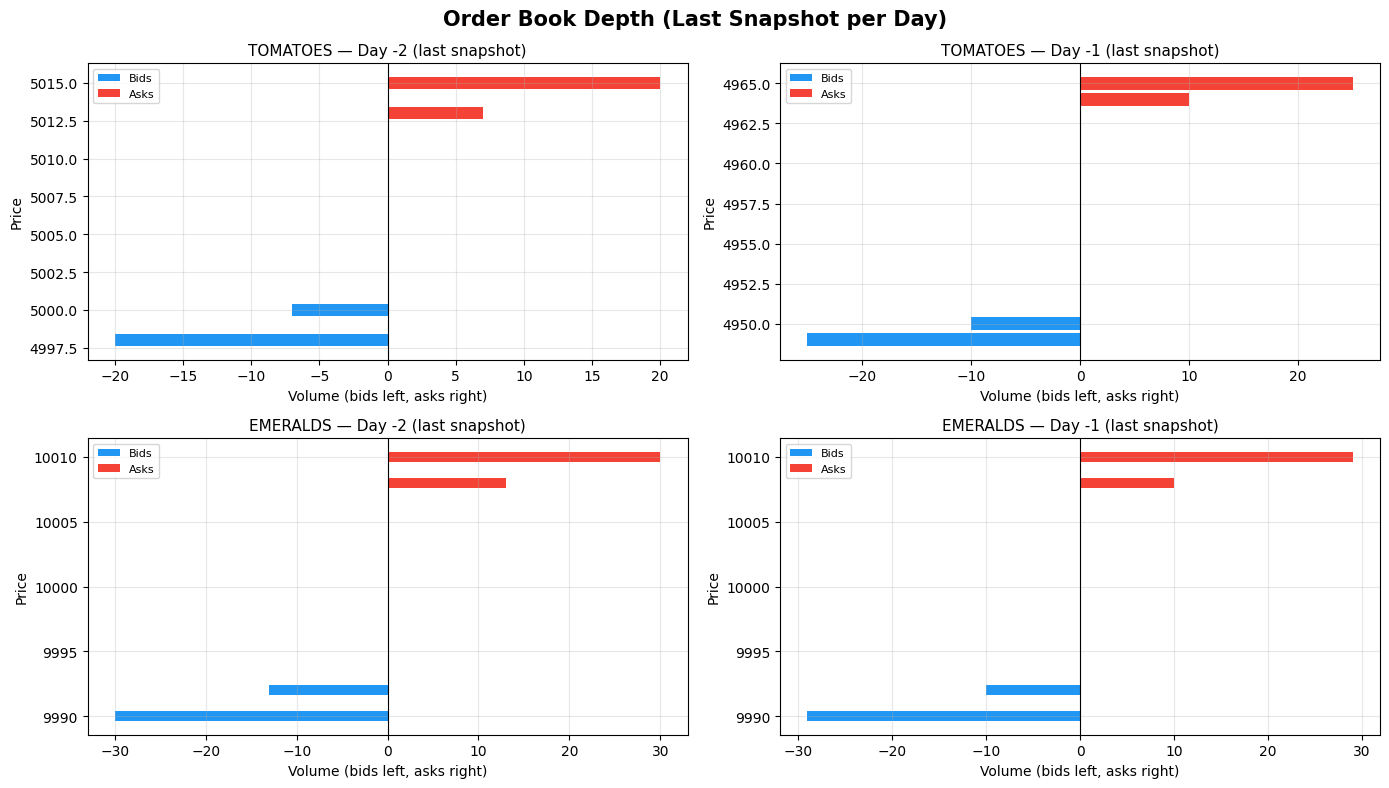

In [11]:
# --- 4. Order Book Depth Snapshot (last timestamp per day) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
bid_vol_cols = ["bid_volume_1", "bid_volume_2", "bid_volume_3"]
ask_vol_cols = ["ask_volume_1", "ask_volume_2", "ask_volume_3"]

for col, (product, day_val) in enumerate([("TOMATOES", -2), ("TOMATOES", -1)]):
    ax = axes[0][col]
    subset = df_prices[(df_prices["product"] == product) & (df_prices["day"] == day_val)]
    snap = subset.iloc[-1]
    bids = [(snap[p], snap[v]) for p, v in zip(bid_cols, bid_vol_cols) if pd.notna(snap[p])]
    asks = [(snap[p], snap[v]) for p, v in zip(ask_cols, ask_vol_cols) if pd.notna(snap[p])]
    if bids:
        bp, bv = zip(*bids)
        ax.barh(bp, [-v for v in bv], color="#2196F3", label="Bids", height=0.8)
    if asks:
        ap, av = zip(*asks)
        ax.barh(ap, av, color="#F44336", label="Asks", height=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"TOMATOES — Day {day_val} (last snapshot)", fontsize=11)
    ax.set_xlabel("Volume (bids left, asks right)")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for col, (product, day_val) in enumerate([("EMERALDS", -2), ("EMERALDS", -1)]):
    ax = axes[1][col]
    subset = df_prices[(df_prices["product"] == product) & (df_prices["day"] == day_val)]
    snap = subset.iloc[-1]
    bids = [(snap[p], snap[v]) for p, v in zip(bid_cols, bid_vol_cols) if pd.notna(snap[p])]
    asks = [(snap[p], snap[v]) for p, v in zip(ask_cols, ask_vol_cols) if pd.notna(snap[p])]
    if bids:
        bp, bv = zip(*bids)
        ax.barh(bp, [-v for v in bv], color="#2196F3", label="Bids", height=0.8)
    if asks:
        ap, av = zip(*asks)
        ax.barh(ap, av, color="#F44336", label="Asks", height=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"EMERALDS — Day {day_val} (last snapshot)", fontsize=11)
    ax.set_xlabel("Volume (bids left, asks right)")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Order Book Depth (Last Snapshot per Day)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

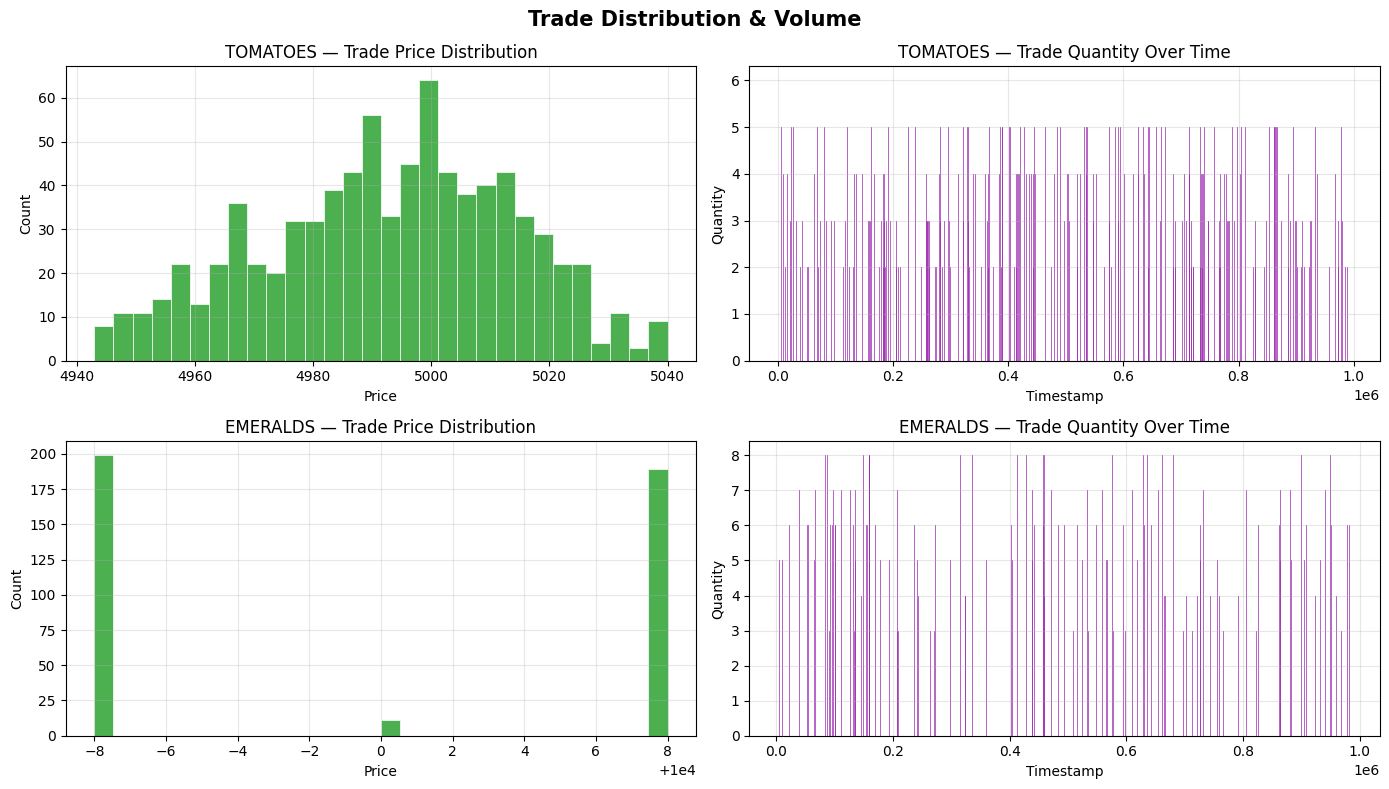

=== Trade Summary ===
          price                                                             \
          count     mean    std     min     25%      50%      75%      max   
symbol                                                                       
EMERALDS  399.0  9999.80   7.90  9992.0  9992.0  10000.0  10008.0  10008.0   
TOMATOES  820.0  4992.57  21.13  4943.0  4978.0   4994.0   5008.0   5040.0   

         quantity                                       
            count  mean   std  min  25%  50%  75%  max  
symbol                                                  
EMERALDS    399.0  5.49  1.63  3.0  4.0  6.0  7.0  8.0  
TOMATOES    820.0  3.48  1.12  2.0  2.0  3.0  4.0  6.0  


In [12]:
# --- 5. Trade Volume & Price Distribution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, product in enumerate(["TOMATOES", "EMERALDS"]):
    trades_sub = df_trades[df_trades["symbol"] == product]

    # Price histogram
    ax_hist = axes[row][0]
    ax_hist.hist(trades_sub["price"], bins=30, color="#4CAF50", edgecolor="white", linewidth=0.5)
    ax_hist.set_title(f"{product} — Trade Price Distribution", fontsize=12)
    ax_hist.set_xlabel("Price")
    ax_hist.set_ylabel("Count")
    ax_hist.grid(True, alpha=0.3)

    # Cumulative volume over time
    ax_vol = axes[row][1]
    ts_sorted = trades_sub.sort_values("timestamp")
    ax_vol.bar(ts_sorted["timestamp"], ts_sorted["quantity"], width=500, color="#9C27B0", alpha=0.7)
    ax_vol.set_title(f"{product} — Trade Quantity Over Time", fontsize=12)
    ax_vol.set_xlabel("Timestamp")
    ax_vol.set_ylabel("Quantity")
    ax_vol.grid(True, alpha=0.3)

plt.suptitle("Trade Distribution & Volume", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary stats
print("=== Trade Summary ===")
print(df_trades.groupby("symbol")[["price", "quantity"]].describe().round(2))

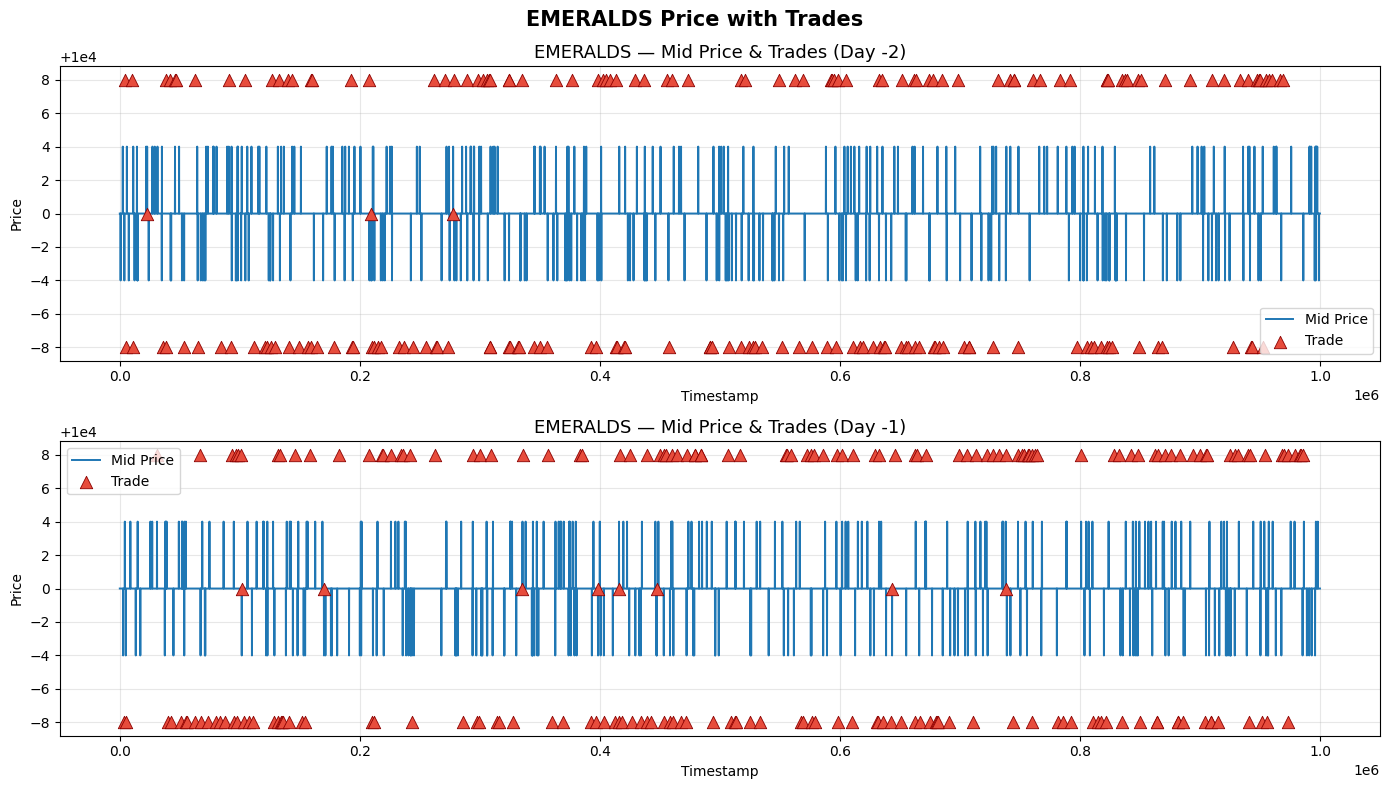

In [13]:
# --- EMERALDS Mid Price with Trade Markers (one graph per day) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

day_configs = [
    (df_prices_two, df_trades_two, -2, "Day -2"),
    (df_prices_one, df_trades_one, -1, "Day -1"),
]

for ax, (df_p, df_t, day_val, day_label) in zip(axes, day_configs):
    emerald_prices = df_p[df_p["product"] == "EMERALDS"].sort_values("timestamp")
    emerald_trades = df_t[df_t["symbol"] == "EMERALDS"]

    # Mid price line
    ax.plot(emerald_prices["timestamp"], emerald_prices["mid_price"],
            color="#1f77b4", linewidth=1.4, label="Mid Price", zorder=2)

    # Trade markers as triangles
    ax.scatter(emerald_trades["timestamp"], emerald_trades["price"],
               marker="^", s=80, color="#e74c3c", zorder=4,
               edgecolors="darkred", linewidths=0.6, label="Trade")

    ax.set_title(f"EMERALDS — Mid Price & Trades ({day_label})", fontsize=13)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("EMERALDS Price with Trades", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

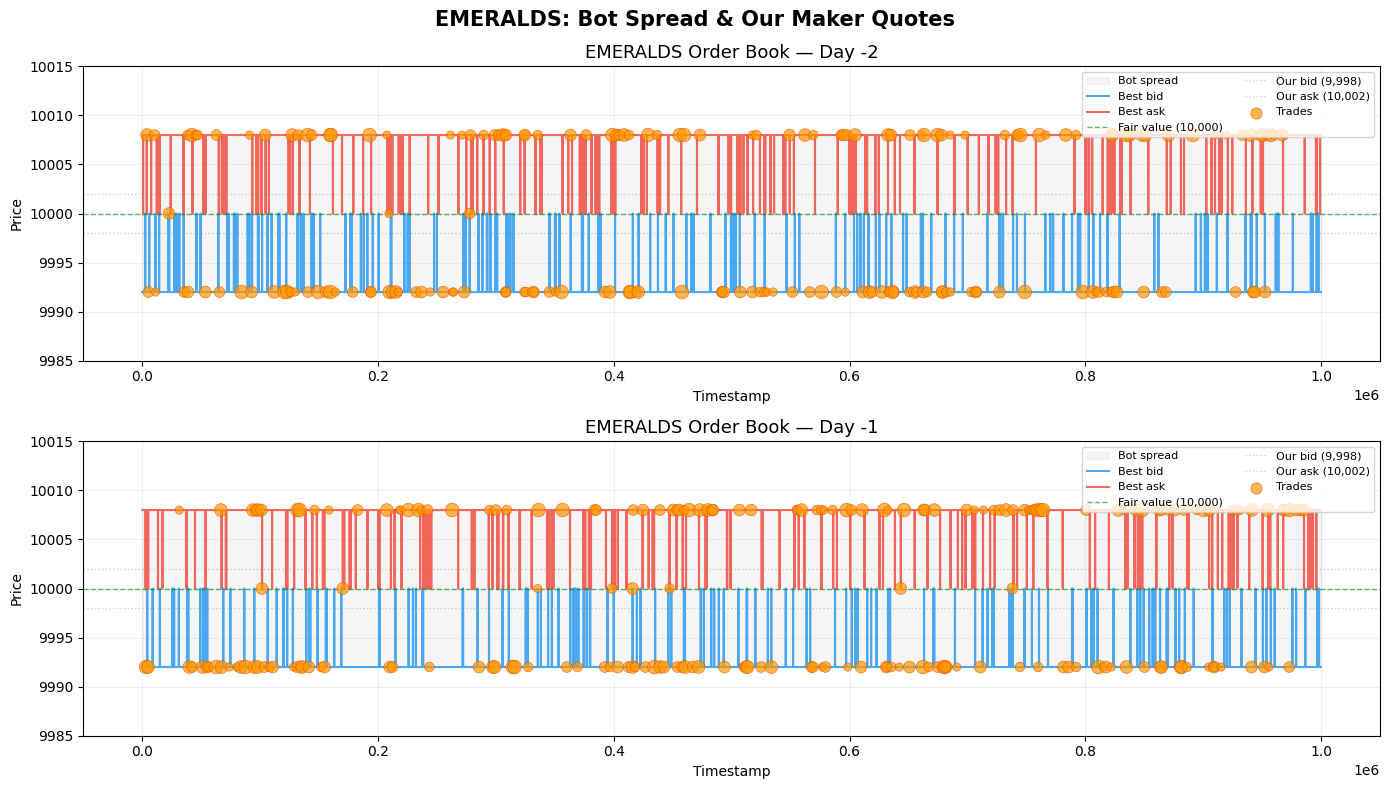

The gray zone is the bot's spread. Our green dotted lines sit INSIDE it.
Trades (orange dots) happen at 9992, 10000, or 10008 — the bot's prices.


In [14]:
# === EMERALDS: Order Book Structure ===
# Shows bid/ask prices over time to reveal the bot's quoting pattern

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, (df_p, df_t, day_val, label) in zip(axes, [
    (df_prices_two, df_trades_two, -2, "Day -2"),
    (df_prices_one, df_trades_one, -1, "Day -1"),
]):
    em = df_p[df_p["product"] == "EMERALDS"].sort_values("timestamp")
    em_t = df_t[df_t["symbol"] == "EMERALDS"]

    # Shade the bot's spread region
    ax.fill_between(em["timestamp"], em["bid_price_1"], em["ask_price_1"],
                    alpha=0.08, color="gray", label="Bot spread")

    # Bid and ask lines
    ax.step(em["timestamp"], em["bid_price_1"], where="post",
            color="#2196F3", linewidth=1.5, label="Best bid", alpha=0.8)
    ax.step(em["timestamp"], em["ask_price_1"], where="post",
            color="#F44336", linewidth=1.5, label="Best ask", alpha=0.8)

    # Fair value
    ax.axhline(10000, color="green", linestyle="--", linewidth=1, alpha=0.6, label="Fair value (10,000)")

    # Our maker quotes (where we'd post)
    ax.axhline(9998, color="#4CAF50", linestyle=":", linewidth=1, alpha=0.4, label="Our bid (9,998)")
    ax.axhline(10002, color="#4CAF50", linestyle=":", linewidth=1, alpha=0.4, label="Our ask (10,002)")

    # Trades
    ax.scatter(em_t["timestamp"], em_t["price"], s=em_t["quantity"] * 12,
               color="#FF9800", edgecolors="#E65100", linewidths=0.5,
               alpha=0.7, zorder=5, label="Trades")

    ax.set_title(f"EMERALDS Order Book — {label}", fontsize=13)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.set_ylim(9985, 10015)
    ax.legend(fontsize=8, loc="upper right", ncol=2)
    ax.grid(True, alpha=0.2)

plt.suptitle("EMERALDS: Bot Spread & Our Maker Quotes", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
print("The gray zone is the bot's spread. Our green dotted lines sit INSIDE it.")
print("Trades (orange dots) happen at 9992, 10000, or 10008 — the bot's prices.")

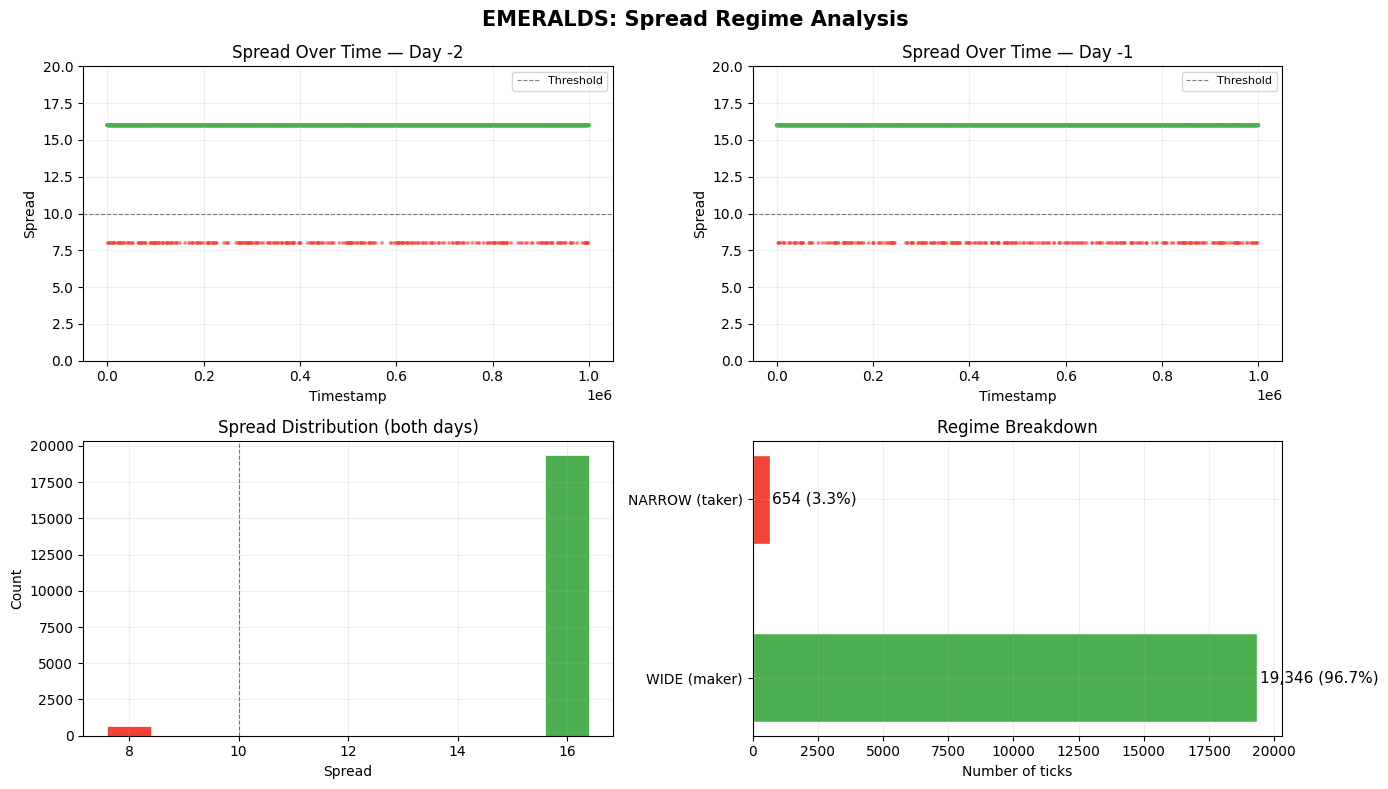

Green = WIDE spread (>10): 19,346 ticks — we act as MAKER
Red = NARROW spread (<=10): 654 ticks — we act as TAKER / sit out


In [15]:
# === EMERALDS: Spread Regime Analysis ===
# When is the spread wide (maker opportunity) vs narrow (taker/flatten)?

df_prices = pd.concat([df_prices_two, df_prices_one], ignore_index=True)
em_all = df_prices[df_prices["product"] == "EMERALDS"].copy()
em_all["spread"] = em_all["ask_price_1"] - em_all["bid_price_1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top left: Spread over time (day -2)
for ax, day_val, label in [(axes[0, 0], -2, "Day -2"), (axes[0, 1], -1, "Day -1")]:
    subset = em_all[em_all["day"] == day_val].sort_values("timestamp")
    colors = ["#4CAF50" if s > 10 else "#F44336" for s in subset["spread"]]
    ax.scatter(subset["timestamp"], subset["spread"], c=colors, s=3, alpha=0.5)
    ax.axhline(10, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="Threshold")
    ax.set_title(f"Spread Over Time — {label}", fontsize=12)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Spread")
    ax.set_ylim(0, 20)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

# Bottom left: Spread distribution
ax = axes[1, 0]
spread_counts = em_all["spread"].value_counts().sort_index()
bar_colors = ["#4CAF50" if s > 10 else "#F44336" for s in spread_counts.index]
ax.bar(spread_counts.index, spread_counts.values, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axvline(10, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Spread Distribution (both days)", fontsize=12)
ax.set_xlabel("Spread")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2)

# Bottom right: Regime stats
ax = axes[1, 1]
wide = (em_all["spread"] > 10).sum()
narrow = (em_all["spread"] <= 10).sum()
ax.barh(["WIDE (maker)", "NARROW (taker)"], [wide, narrow],
        color=["#4CAF50", "#F44336"], edgecolor="white", height=0.5)
ax.set_title("Regime Breakdown", fontsize=12)
ax.set_xlabel("Number of ticks")
for i, v in enumerate([wide, narrow]):
    pct = v / (wide + narrow) * 100
    ax.text(v + 100, i, f"{v:,} ({pct:.1f}%)", va="center", fontsize=11)
ax.grid(True, alpha=0.2)

plt.suptitle("EMERALDS: Spread Regime Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Green = WIDE spread (>10): {wide:,} ticks — we act as MAKER")
print(f"Red = NARROW spread (<=10): {narrow:,} ticks — we act as TAKER / sit out")

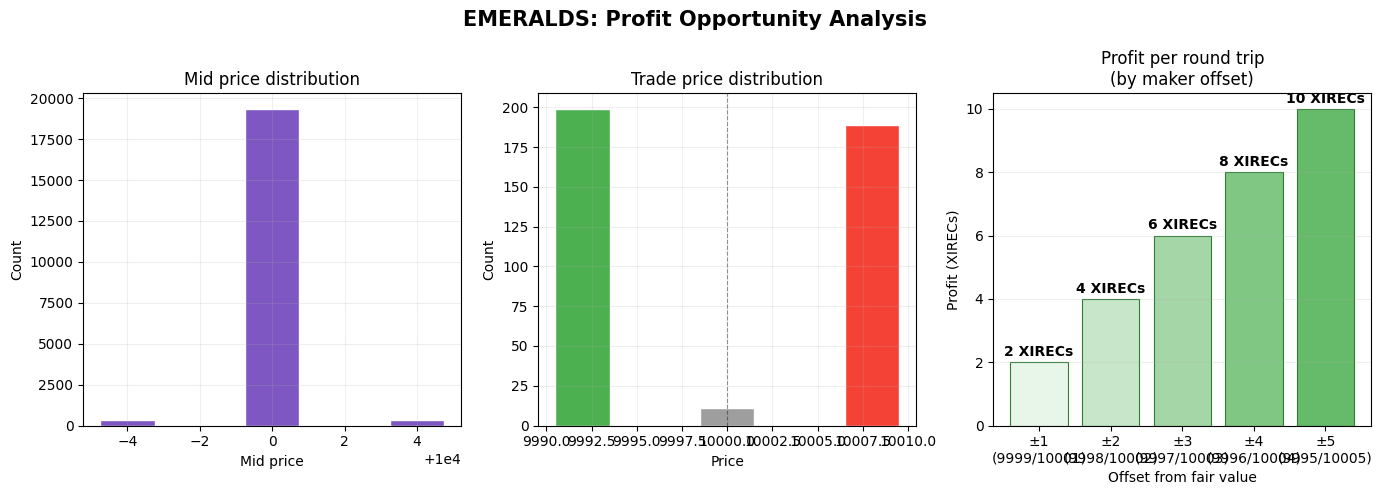

Green trades = below fair value (buy opportunities)
Red trades = above fair value (sell opportunities)
Gray trades = at fair value (no edge)

Our algo uses offset ±2 → 4 XIRECs per round trip
Total trades in data: 399, avg qty: 5.5


In [16]:
# === EMERALDS: Where the Profit Lives ===
# Shows the mid price values and trade price distribution

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Mid price distribution
ax = axes[0]
mid_counts = em_all["mid_price"].value_counts().sort_index()
ax.bar(mid_counts.index, mid_counts.values, width=1.5,
       color="#7E57C2", edgecolor="white")
ax.set_title("Mid price distribution", fontsize=12)
ax.set_xlabel("Mid price")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2)

# 2. Trade prices
ax = axes[1]
df_trades = pd.concat([df_trades_two, df_trades_one], ignore_index=True)
em_trades = df_trades[df_trades["symbol"] == "EMERALDS"]
trade_price_counts = em_trades["price"].value_counts().sort_index()
trade_colors = []
for p in trade_price_counts.index:
    if p < 10000:
        trade_colors.append("#4CAF50")  # buy opportunity
    elif p > 10000:
        trade_colors.append("#F44336")  # sell opportunity
    else:
        trade_colors.append("#9E9E9E")  # at fair value
ax.bar(trade_price_counts.index, trade_price_counts.values, width=3,
       color=trade_colors, edgecolor="white")
ax.axvline(10000, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
ax.set_title("Trade price distribution", fontsize=12)
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2)

# 3. Theoretical profit per round trip
ax = axes[2]
offsets = [1, 2, 3, 4, 5]
spreads = [o * 2 for o in offsets]
labels = [f"±{o}\n({10000-o}/{10000+o})" for o in offsets]
ax.bar(labels, spreads, color=["#E8F5E9", "#C8E6C9", "#A5D6A7", "#81C784", "#66BB6A"],
       edgecolor="#2E7D32", linewidth=0.8)
for i, (l, s) in enumerate(zip(labels, spreads)):
    ax.text(i, s + 0.2, f"{s} XIRECs", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Profit per round trip\n(by maker offset)", fontsize=12)
ax.set_xlabel("Offset from fair value")
ax.set_ylabel("Profit (XIRECs)")
ax.grid(True, alpha=0.2, axis="y")

plt.suptitle("EMERALDS: Profit Opportunity Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
print("Green trades = below fair value (buy opportunities)")
print("Red trades = above fair value (sell opportunities)")
print("Gray trades = at fair value (no edge)")
print(f"\nOur algo uses offset ±2 → 4 XIRECs per round trip")
print(f"Total trades in data: {len(em_trades)}, avg qty: {em_trades['quantity'].mean():.1f}")

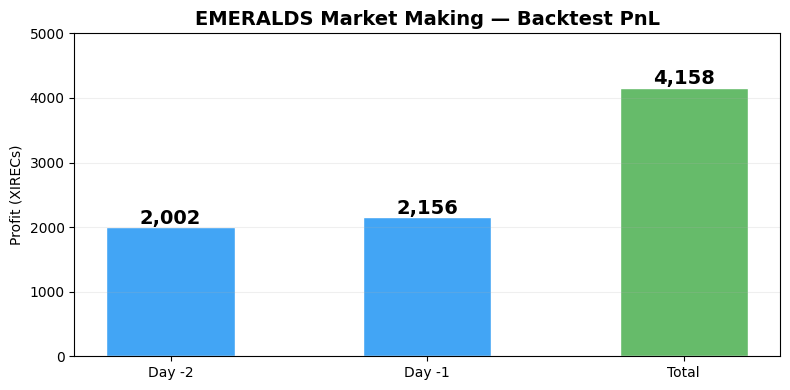

Strategy: Maker inside bot spread (bid 9998 / ask 10002)
With position-based skewing and spread-regime switching
Average daily PnL: 2,079 XIRECs


In [17]:
# === EMERALDS: Backtest Summary ===
# Results from running our market-making algo against tutorial data

fig, ax = plt.subplots(figsize=(8, 4))

days = ["Day -2", "Day -1", "Total"]
pnl = [2002, 2156, 4158]
colors = ["#42A5F5", "#42A5F5", "#66BB6A"]

bars = ax.bar(days, pnl, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, pnl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontsize=14, fontweight="bold")

ax.set_title("EMERALDS Market Making — Backtest PnL", fontsize=14, fontweight="bold")
ax.set_ylabel("Profit (XIRECs)")
ax.set_ylim(0, 5000)
ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()
print("Strategy: Maker inside bot spread (bid 9998 / ask 10002)")
print("With position-based skewing and spread-regime switching")
print(f"Average daily PnL: {(2002+2156)/2:,.0f} XIRECs")